<a href="https://colab.research.google.com/github/marygizem/-Machine-Learning-and-Predictive-Analytics/blob/main/Updated_Week_8_Homework_Initial_Project_Forecasting_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forecasting Model (Week 7)

This notebook develops a sales forecasting model using historical transaction data. It includes feature engineering, visualization, model comparison, and forecasting for the next three months.

In [4]:
from google.colab import files
files.upload()

Saving merged_data.csv to merged_data.csv


{'merged_data.csv': b'Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price_x,Total_Cost,Company_Name,Company_Profit,Address,Product_Name,Product_Price_y\n2.0,29.0,19.0,16.0,2021-02-21,97930.9933803618,1428000.0,Sky  Industries  29,61952.0,"Edsa, brgy. 606, makati, philippines!",EcoNomix Modeler,"?95,200"\n5.0,47.0,3.0,8.0,2021-02-21,99575.60963363378,705600.0,Green  Industries  47,31130.0,"Taft Ave, Barangay 707, Mandaluyong, Philippines",TrendWise Forecaster,"?100,800"\n6.0,80.0,11.0,4.0,2021-07-12,160658.67535045007,627200.0,Green  Partners  80,111227.0,"Commonwealth Ave, Barangay 202, Manila, Philippines",OptiFlow Automation,"?156,800"\n8.0,21.0,20.0,7.0,2021-02-21,229217.9414680993,1792000.0,Dynamic Enterprises 21,,"Ortigas Ave, Barangay 707, Davao City, Philippines",FinSphere Intelligence Suite,"?224,000"\n10.0,3.0,20.0,6.0,2021-02-21,238293.8513034097,1120000.0,Quantum Associates 3,110664.0,"Roxas Blvd, Barangay 505, Pasig, Philippines",FinSphere Intellige

In [5]:
import os
print(os.listdir())

['.config', 'merged_data.csv', 'sample_data']


In [6]:
import pandas as pd

merged_data = pd.read_csv("merged_data.csv")
print(merged_data.head())

   Transaction_ID  Company_ID  Product_ID  Quantity Transaction_Date  \
0             2.0        29.0        19.0      16.0       2021-02-21   
1             5.0        47.0         3.0       8.0       2021-02-21   
2             6.0        80.0        11.0       4.0       2021-07-12   
3             8.0        21.0        20.0       7.0       2021-02-21   
4            10.0         3.0        20.0       6.0       2021-02-21   

   Product_Price_x  Total_Cost            Company_Name  Company_Profit  \
0     97930.993380   1428000.0     Sky  Industries  29         61952.0   
1     99575.609634    705600.0   Green  Industries  47         31130.0   
2    160658.675350    627200.0     Green  Partners  80        111227.0   
3    229217.941468   1792000.0  Dynamic Enterprises 21             NaN   
4    238293.851303   1120000.0    Quantum Associates 3        110664.0   

                                             Address  \
0              Edsa, brgy. 606, makati, philippines!   
1   Taft A

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# convert date column
merged_data["Transaction_Date"] = pd.to_datetime(merged_data["Transaction_Date"], errors="coerce")

# remove rows with invalid dates
merged_data = merged_data.dropna(subset=["Transaction_Date"])

# create monthly period
merged_data["YearMonth"] = merged_data["Transaction_Date"].dt.to_period("M")

print(merged_data[["Transaction_Date", "YearMonth"]].head())

  Transaction_Date YearMonth
0       2021-02-21   2021-02
1       2021-02-21   2021-02
2       2021-07-12   2021-07
3       2021-02-21   2021-02
4       2021-02-21   2021-02


## Monthly Sales Aggregation

This section aggregates the historical transaction data into monthly sales so the dataset can be used for forecasting.

In [8]:
monthly_sales = merged_data.groupby("YearMonth").agg(
    total_sales=("Total_Cost", "sum"),
    total_quantity=("Quantity", "sum"),
    avg_price=("Product_Price_x", "mean"),
    transaction_count=("Transaction_ID", "count")
).reset_index()

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

print(monthly_sales.head())
print(monthly_sales.shape)

  YearMonth   total_sales  total_quantity      avg_price  transaction_count
0   2020-10  4.849600e+06            32.0  148327.692927                  3
1   2020-11  4.777360e+07           368.0  136653.572830                 33
2   2020-12  2.880640e+07           204.0  136438.763122                 21
3   2021-01  4.709600e+07           347.0  137383.563346                 35
4   2021-02  5.694074e+09         41954.0  135119.607704               3999
(49, 5)


## Sales Trend Visualization

This chart shows the monthly sales pattern over time and helps identify overall trends in the data.

## Time Series Analysis

The dataset was transformed into a time-series format by aggregating sales monthly. This allows the model to capture trends, seasonality, and patterns over time.

Time-based features and lag variables were created to simulate time-series forecasting behavior, where past values influence future predictions.

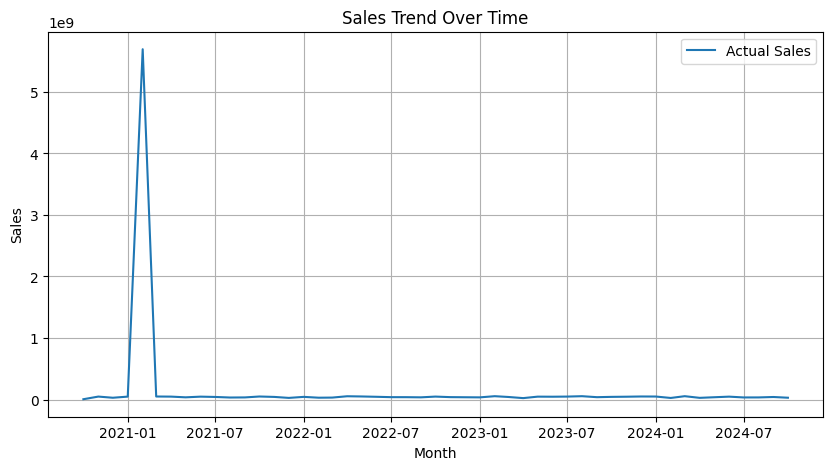

In [28]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["total_sales"], label="Actual Sales")
plt.title("Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Feature Engineering

This section creates new forecasting features such as month, quarter, lag values, and rolling averages to help improve prediction accuracy.

In [10]:
monthly_sales["YearMonth"] = pd.to_datetime(monthly_sales["YearMonth"])

# time-based features
monthly_sales["month"] = monthly_sales["YearMonth"].dt.month
monthly_sales["quarter"] = monthly_sales["YearMonth"].dt.quarter

# lag features
monthly_sales["lag_1"] = monthly_sales["total_sales"].shift(1)
monthly_sales["lag_2"] = monthly_sales["total_sales"].shift(2)
monthly_sales["lag_3"] = monthly_sales["total_sales"].shift(3)

# rolling feature
monthly_sales["rolling_3"] = monthly_sales["total_sales"].rolling(3).mean()

# drop rows with null values created by lag/rolling operations
monthly_sales = monthly_sales.dropna().reset_index(drop=True)

print(monthly_sales.head())
print(monthly_sales.shape)

   YearMonth   total_sales  total_quantity      avg_price  transaction_count  \
0 2021-01-01  4.709600e+07           347.0  137383.563346                 35   
1 2021-02-01  5.694074e+09         41954.0  135119.607704               3999   
2 2021-03-01  4.901680e+07           385.0  126132.230470                 37   
3 2021-04-01  4.713520e+07           370.0  126509.331814                 32   
4 2021-05-01  3.565520e+07           278.0  128247.636309                 27   

   month  quarter         lag_1         lag_2         lag_3     rolling_3  
0      1        1  2.880640e+07  4.777360e+07  4.849600e+06  4.122533e+07  
1      2        1  4.709600e+07  2.880640e+07  4.777360e+07  1.923326e+09  
2      3        1  5.694074e+09  4.709600e+07  2.880640e+07  1.930062e+09  
3      4        2  4.901680e+07  5.694074e+09  4.709600e+07  1.930075e+09  
4      5        2  4.713520e+07  4.901680e+07  5.694074e+09  4.393573e+07  
(46, 11)


## Correlation Analysis

This heatmap helps assess the relationship between engineered features and total sales.

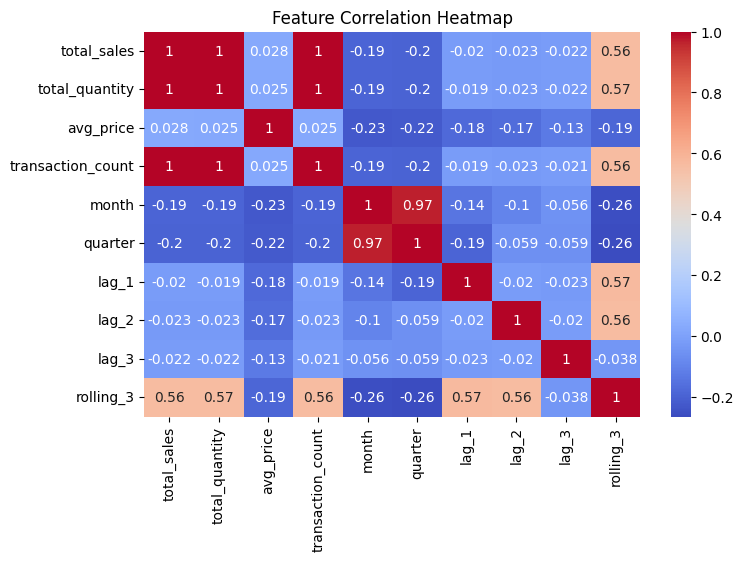

In [11]:
plt.figure(figsize=(8, 5))
sns.heatmap(monthly_sales.drop(columns=["YearMonth"]).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Additional Model (ARIMA)

An ARIMA model was also tested as a traditional time-series forecasting method. This model uses past values and trends to generate future predictions without requiring feature engineering.

Comparing machine learning models and ARIMA provides a broader evaluation of forecasting approaches.

In [29]:
from statsmodels.tsa.arima.model import ARIMA

# simple ARIMA model
model_arima = ARIMA(monthly_sales["total_sales"], order=(1,1,1))
model_arima_fit = model_arima.fit()

forecast_arima = model_arima_fit.forecast(steps=3)

print("ARIMA Forecast:")
print(forecast_arima)

ARIMA Forecast:
49    1.542116e+08
50    1.523295e+08
51    1.523578e+08
Name: predicted_mean, dtype: float64


## Model Development and Comparison

This section develops two forecasting models, Linear Regression and Random Forest, and compares their results using error metrics.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# keep time order: last 3 months for testing
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

X_train = train.drop(columns=["YearMonth", "total_sales"])
y_train = train["total_sales"]

X_test = test.drop(columns=["YearMonth", "total_sales"])
y_test = test["total_sales"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (43, 9)
Test shape: (3, 9)


In [13]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 2.384185791015625e-07
Linear Regression RMSE: 2.892002786797213e-07


In [15]:
# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 2657349.3333333335
Random Forest RMSE: 3411107.94644399


In [16]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

print(comparison)

               Model           MAE          RMSE
0  Linear Regression  2.384186e-07  2.892003e-07
1      Random Forest  2.657349e+06  3.411108e+06


## Forecasting Results

This section presents the actual sales values and the forecasted values for the test period.

In [17]:
results = pd.DataFrame({
    "Month": test["YearMonth"].astype(str).values,
    "Actual_Sales": y_test.values,
    "LR_Forecast": lr_pred,
    "RF_Forecast": rf_pred
})

print(results)

        Month  Actual_Sales  LR_Forecast  RF_Forecast
0  2024-08-01    34092800.0   34092800.0   35539280.0
1  2024-09-01    40952800.0   40952800.0   40090344.0
2  2024-10-01    29131200.0   29131200.0   34794312.0


In [26]:
print(monthly_sales.dtypes)

YearMonth            datetime64[ns]
total_sales                 float64
total_quantity              float64
avg_price                   float64
transaction_count             int64
dtype: object


In [27]:
# =========================
# FORECAST NEXT 3 MONTHS
# =========================

future_predictions = []
last_data = monthly_sales.copy()

for i in range(3):
    next_month = last_data["YearMonth"].iloc[-1] + pd.DateOffset(months=1)

    future_row = {}
    future_row["YearMonth"] = next_month
    future_row["month"] = next_month.month
    future_row["quarter"] = next_month.quarter
    future_row["lag_1"] = last_data["total_sales"].iloc[-1]
    future_row["lag_2"] = last_data["total_sales"].iloc[-2]
    future_row["lag_3"] = last_data["total_sales"].iloc[-3]
    future_row["rolling_3"] = last_data["total_sales"].iloc[-3:].mean()
    future_row["total_quantity"] = last_data["total_quantity"].iloc[-3:].mean()
    future_row["avg_price"] = last_data["avg_price"].iloc[-3:].mean()
    future_row["transaction_count"] = last_data["transaction_count"].iloc[-3:].mean()

    future_df_row = pd.DataFrame([future_row])
    X_future = future_df_row[X_train.columns]

    pred = rf_model.predict(X_future)[0]

    future_predictions.append({
        "Month": next_month.strftime("%Y-%m"),
        "Forecasted_Sales": pred
    })

    future_row["total_sales"] = pred
    last_data = pd.concat([last_data, pd.DataFrame([future_row])], ignore_index=True)

future_forecast = pd.DataFrame(future_predictions)
print(future_forecast)

     Month  Forecasted_Sales
0  2024-11        36206072.0
1  2024-12        35546672.0
2  2025-01        35598136.0


## Interpretation

Monthly sales data was created from historical transactions and enhanced using time-based, lag-based, and rolling average features. Two algorithms were tested: Linear Regression and Random Forest. Their performance was compared using MAE and RMSE, and the better-performing model can be selected for future sales forecasting. This forecasting workflow helps businesses anticipate future demand and support planning and decision-making.